## Notebook for testing different resolutions of the model

In [13]:
import torch
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
import glob
import PIL.Image
import os
import numpy as np
import pandas as pd

DATASET_NAME = 'dataset_labeled_4_fast'
DATASET_DIR  = 'datasets/' + DATASET_NAME

RESOLUTIONS  = [112, 224]
MODEL_NAMES  = ['resnet18', 'mobilenet_v2']

_label_cache = {}
def _load_labels(csv_file):
    if csv_file not in _label_cache:
        df = pd.read_csv(csv_file)
        _label_cache[csv_file] = {os.path.basename(r['image_path']): (r['x_norm'], r['y_norm']) for _, r in df.iterrows()}
    return _label_cache[csv_file]

def get_x(path, width, csv_file=f'{DATASET_DIR}/labels.csv'):
    return _load_labels(csv_file)[os.path.basename(path)][0]

def get_y(path, height, csv_file=f'{DATASET_DIR}/labels.csv'):
    return _load_labels(csv_file)[os.path.basename(path)][1]

def augment_image(image, x, y, max_crop=0.8):
    W, H = image.size
    scale = np.random.uniform(max_crop, 1.0)
    crop_w, crop_h = int(W * scale), int(H * scale)
    left = np.random.randint(0, W - crop_w + 1)
    top  = np.random.randint(0, H - crop_h + 1)
    image = transforms.functional.crop(image, top, left, crop_h, crop_w)
    x_new = (x * W - left) / crop_w
    y_new = (y * H - top)  / crop_h
    image = transforms.functional.resize(image, (H, W))
    return image, x_new, y_new

class XYDataset(torch.utils.data.Dataset):
    def __init__(self, directory, resolution, random_hflips=False, augment=False):
        self.directory     = directory
        self.resolution    = resolution
        self.random_hflips = random_hflips
        self.augment       = augment
        self.image_paths   = glob.glob(os.path.join(self.directory, '*.jpg'))
        self.color_jitter  = transforms.ColorJitter(0.3, 0.3, 0.3, 0.3)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = PIL.Image.open(image_path)
        image = transforms.functional.resize(image, (self.resolution, self.resolution))
        width, height = image.size
        x = float(get_x(os.path.basename(image_path), width))
        y = float(get_y(os.path.basename(image_path), height))
        if self.random_hflips and float(np.random.rand(1)) > 0.5:
            image = transforms.functional.hflip(image)
            x = 1 - x
        if self.augment:
            image, x, y = augment_image(image, x, y)
        image = self.color_jitter(image)
        image = transforms.functional.to_tensor(image)
        image = image.numpy()[::-1].copy()
        image = torch.from_numpy(image)
        image = transforms.functional.normalize(image, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        return image, torch.tensor([x, y]).float()

def build_model(model_name):
    if model_name == 'resnet18':
        m = models.resnet18(pretrained=True)
        m.fc = torch.nn.Linear(512, 2)
    elif model_name == 'mobilenet_v2':
        m = models.mobilenet_v2(pretrained=True)
        m.classifier[1] = torch.nn.Linear(1280, 2)
    else:
        raise ValueError(f'Unknown model: {model_name}')
    return m

def model_path(model_name, resolution):
    return f'models/{DATASET_NAME}/best_{model_name}_{resolution}.pth'


## Training itself (can be skipped)

In [14]:
NUM_EPOCHS   = 70
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

os.makedirs(f'models/{DATASET_NAME}', exist_ok=True)

# Fixed split — same images for every model/resolution combination
_ref_dataset = XYDataset(DATASET_DIR, resolution=224)
n        = len(_ref_dataset)
indices  = torch.randperm(n).tolist()
n_train  = int(0.8 * n)
n_val    = int(0.1 * n)
TRAIN_IDX = indices[:n_train]
VAL_IDX   = indices[n_train:n_train + n_val]
TEST_IDX  = indices[n_train + n_val:]
print(f'Split — train: {len(TRAIN_IDX)}, val: {len(VAL_IDX)}, test: {len(TEST_IDX)}')

for model_name in MODEL_NAMES:
    for resolution in RESOLUTIONS:
        print(f'\n{"="*55}\n{model_name}  {resolution}x{resolution}\n{"="*55}')

        dataset      = XYDataset(DATASET_DIR, resolution=resolution, random_hflips=True, augment=True)
        train_loader = torch.utils.data.DataLoader(torch.utils.data.Subset(dataset, TRAIN_IDX), batch_size=8, shuffle=True,  num_workers=0)
        val_loader   = torch.utils.data.DataLoader(torch.utils.data.Subset(dataset, VAL_IDX),   batch_size=8, shuffle=False, num_workers=0)

        model = build_model(model_name).to(device)
        best_loss = 1e9
        optimizer = optim.Adam(model.parameters())
        save_path = model_path(model_name, resolution)

        for epoch in range(NUM_EPOCHS):
            print(f'  Epoch {epoch+1}/{NUM_EPOCHS}', end='\r')
            model.train()
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                F.mse_loss(model(images), labels).backward()
                optimizer.step()

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for images, labels in val_loader:
                    val_loss += float(F.mse_loss(model(images.to(device)), labels.to(device)))
            val_loss /= len(val_loader)

            if val_loss < best_loss:
                torch.save(model.state_dict(), save_path)
                best_loss = val_loss

            if (epoch + 1) % 10 == 0:
                print(f'  Epoch {epoch+1}/{NUM_EPOCHS} — Val Loss: {val_loss:.4f}')

print('\nAll models trained.')

Using device: cuda
Split — train: 356, val: 44, test: 45

resnet18  112x112
  Epoch 10/70 — Val Loss: 0.0106
  Epoch 20/70 — Val Loss: 0.0056
  Epoch 30/70 — Val Loss: 0.0063
  Epoch 40/70 — Val Loss: 0.0072
  Epoch 50/70 — Val Loss: 0.0056
  Epoch 60/70 — Val Loss: 0.0084
  Epoch 70/70 — Val Loss: 0.0035

resnet18  224x224
  Epoch 10/70 — Val Loss: 0.0141
  Epoch 20/70 — Val Loss: 0.0076
  Epoch 30/70 — Val Loss: 0.0031
  Epoch 40/70 — Val Loss: 0.0023
  Epoch 50/70 — Val Loss: 0.0028
  Epoch 60/70 — Val Loss: 0.0013
  Epoch 70/70 — Val Loss: 0.0021

mobilenet_v2  112x112
  Epoch 10/70 — Val Loss: 0.0081
  Epoch 20/70 — Val Loss: 0.0036
  Epoch 30/70 — Val Loss: 0.0018
  Epoch 40/70 — Val Loss: 0.0023
  Epoch 50/70 — Val Loss: 0.0020
  Epoch 60/70 — Val Loss: 0.0018
  Epoch 70/70 — Val Loss: 0.0030

mobilenet_v2  224x224
  Epoch 10/70 — Val Loss: 0.0066
  Epoch 20/70 — Val Loss: 0.0064
  Epoch 30/70 — Val Loss: 0.0027
  Epoch 40/70 — Val Loss: 0.0026
  Epoch 50/70 — Val Loss: 0.0019
 

In [15]:
import random
import numpy as np
import pandas as pd
import torch
import torchvision.transforms as transforms
import PIL.Image
import os
from datetime import datetime

device = torch.device('cuda')

def get_image_tensor(image_path, res):
    transform = transforms.Compose([
        transforms.Resize((res, res)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    return transform(PIL.Image.open(image_path).convert('RGB'))

results = []

for model_name in MODEL_NAMES:
    for resolution in RESOLUTIONS:
        m = build_model(model_name)
        m.load_state_dict(torch.load(model_path(model_name, resolution), map_location=device))
        m.to(device)
        m.eval()

        # Warmup
        dummy = torch.zeros(1, 3, resolution, resolution).to(device)
        with torch.no_grad():
            for _ in range(20):
                m(dummy)

        dataset = XYDataset(DATASET_DIR, resolution=resolution)
        samples = [dataset.image_paths[i] for i in TEST_IDX]
        random.shuffle(samples)

        euclidean_errors = []
        inference_times  = []

        for s in samples:
            image = PIL.Image.open(s)
            width, height = image.size
            true_x = get_x(os.path.basename(s), width)
            true_y = get_y(os.path.basename(s), height)

            t0 = datetime.now()
            with torch.no_grad():
                output = m(get_image_tensor(s, resolution).unsqueeze(0).to(device))[0].cpu().numpy()
            inference_times.append((datetime.now() - t0).total_seconds())

            dist_norm = np.sqrt((output[0] - true_x)**2 + (output[1] - true_y)**2)
            euclidean_errors.append(dist_norm * 224)

        avg_time = np.mean(inference_times)
        avg_dist = np.mean(euclidean_errors)

        results.append({
            'Model':                         model_name,
            'Resolution':                    f'{resolution}x{resolution}',
            'Avg Inference (ms)':            round(avg_time * 1000, 1),
            'FPS':                           round(1.0 / avg_time, 1),
            'Avg Euclidean Error (px@224)':  round(avg_dist, 2),
        })

print('\n' + '='*70)
print('BENCHMARK SUMMARY')
print('='*70)
df = pd.DataFrame(results)
print(df.to_string(index=False))
print('='*70)
print('* Euclidean error expressed in pixels relative to a 224x224 reference frame.')


BENCHMARK SUMMARY
        Model Resolution  Avg Inference (ms)    FPS  Avg Euclidean Error (px@224)
     resnet18    112x112                 4.2  238.9                          9.75
     resnet18    224x224                 4.5  220.1                          8.32
 mobilenet_v2    112x112                 6.0  167.7                         10.64
 mobilenet_v2    224x224                 4.6  219.4                         12.60
* Euclidean error expressed in pixels relative to a 224x224 reference frame.


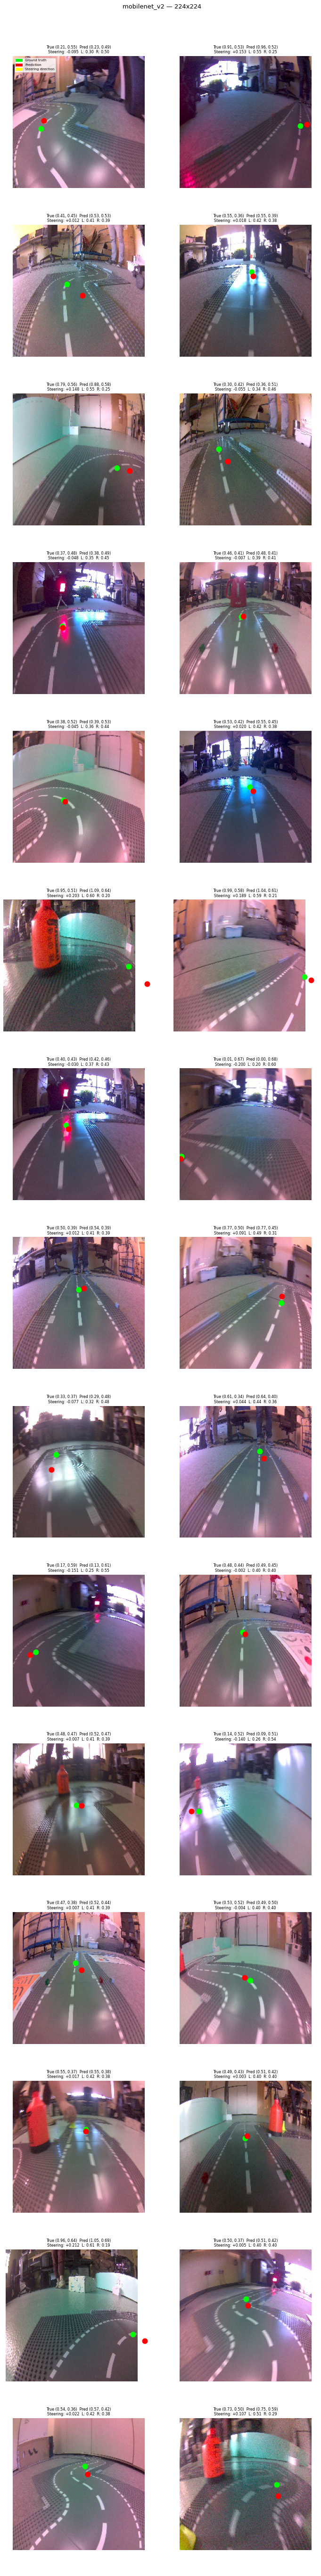

In [17]:
# Cell 3 — Visualise predictions
# Requires Cell 1 scope: DATASET_NAME, DATASET_DIR, TEST_IDX, device,
#                        XYDataset, get_x, get_y, build_model, model_path
# Requires Cell 2 scope: get_image_tensor

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import random
import torch
import PIL.Image
import os
from torchvision import transforms

RESOLUTION  = 224               # ← change to 56 or 112 to inspect other resolutions
MODEL_NAME  = 'mobilenet_v2'        # ← change to 'mobilenet_v2' to inspect other model
N_SAMPLES   = 30
SPEED_GAIN  = 0.4

m = build_model(MODEL_NAME)
m.load_state_dict(torch.load(model_path(MODEL_NAME, RESOLUTION), map_location=device))
m.to(device)
m.eval()

dataset_vis = XYDataset(DATASET_DIR, resolution=RESOLUTION)
samples = [dataset_vis.image_paths[i] for i in TEST_IDX]
random.shuffle(samples)
samples = samples[:N_SAMPLES]

def compute_steering(pred_x, pred_y, speed_gain=SPEED_GAIN, steering_gain=0.2):
    x = pred_x - 0.5
    y = 1 - pred_y
    angle = np.arctan2(x, y)
    steering = angle * steering_gain
    left  = max(min(speed_gain + steering, 1.0), 0.0)
    right = max(min(speed_gain - steering, 1.0), 0.0)
    return angle, steering, left, right

cols = 2
rows = (N_SAMPLES + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
axes = axes.flatten()

for i, s in enumerate(samples):
    image = PIL.Image.open(s).convert('RGB')
    image = transforms.functional.resize(image, (RESOLUTION, RESOLUTION))
    width, height = image.size
    true_x = get_x(os.path.basename(s), width)
    true_y = get_y(os.path.basename(s), height)

    with torch.no_grad():
        output = m(get_image_tensor(s, RESOLUTION).unsqueeze(0).to(device))[0].cpu().numpy()
    pred_x, pred_y = output[0], output[1]

    angle, steering, left, right = compute_steering(pred_x, pred_y)

    ax = axes[i]
    ax.imshow(image)
    ax.scatter(true_x * width, true_y * height, color='lime', s=120, zorder=5)
    ax.scatter(pred_x * width, pred_y * height, color='red',  s=120, zorder=5)

    arrow_base_x = width / 2
    arrow_base_y = height * 0.9
    dx = (pred_x - 0.5) * width * 0.6
    dy = -(pred_y - 0.9) * height * 0.6
    ax.annotate('', xy=(arrow_base_x + dx, arrow_base_y + dy),
                xytext=(arrow_base_x, arrow_base_y),
                arrowprops=dict(arrowstyle='->', color='yellow', lw=2.5))

    ax.set_title(
        f'True ({true_x:.2f}, {true_y:.2f})  Pred ({pred_x:.2f}, {pred_y:.2f})\n'
        f'Steering: {steering:+.3f}  L: {left:.2f}  R: {right:.2f}',
        fontsize=8
    )
    ax.axis('off')

axes[0].legend(handles=[
    mpatches.Patch(color='lime',   label='Ground truth'),
    mpatches.Patch(color='red',    label='Prediction'),
    mpatches.Patch(color='yellow', label='Steering direction'),
], fontsize=7, loc='upper left')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'{MODEL_NAME} — {RESOLUTION}x{RESOLUTION}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()